In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


In [2]:
train_pd = pd.read_csv('/kaggle/input/playground-series-s5e10/train.csv')
train_pd.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [3]:
numerical_features = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents', 'accident_risk']
categorical_features = ['road_type', 'lighting', 'weather', 'road_signs_present', 'public_road', 'time_of_day', 'holiday', 'school_season']

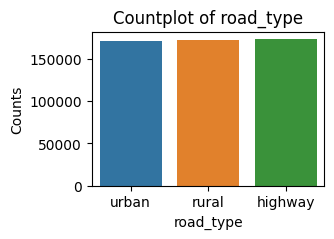

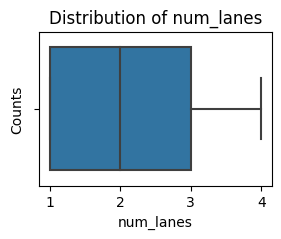

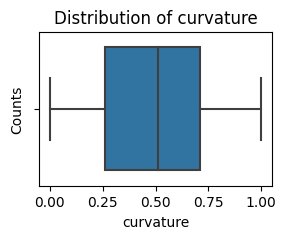

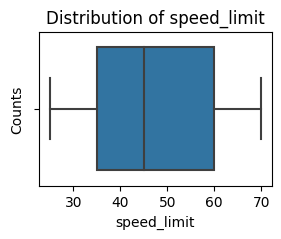

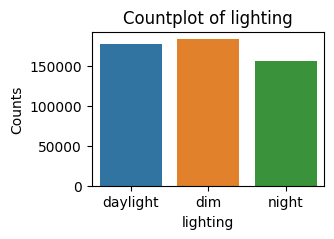

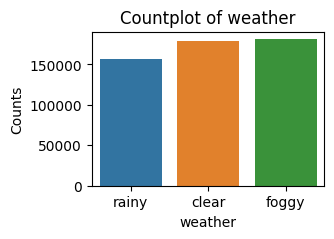

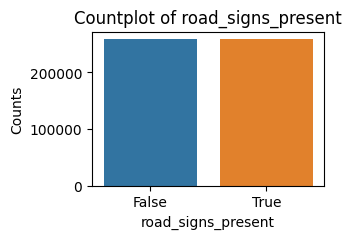

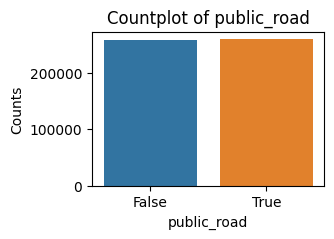

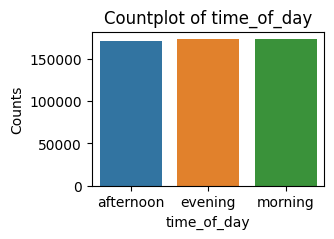

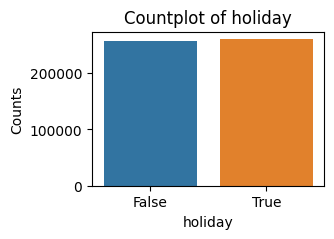

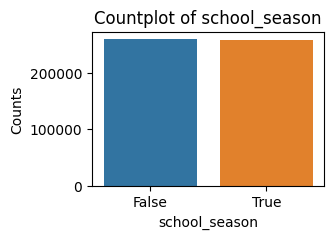

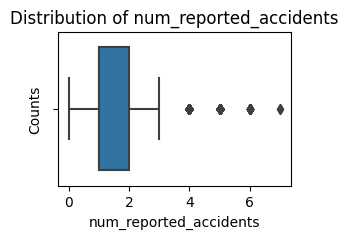

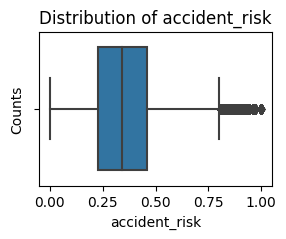

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

for feature in train_pd.columns:
    if feature in numerical_features:
        plt.figure(figsize=(3, 2))
        sns.boxplot(data=train_pd, x=feature)  # kde + bins for smoother look
        plt.xlabel(feature)
        plt.ylabel("Counts")
        plt.title(f"Distribution of {feature}")
        plt.show()
        
    elif feature in categorical_features:
        plt.figure(figsize=(3, 2))
        sns.countplot(data=train_pd, x=feature)  # countplot instead of barplot
        plt.xlabel(feature)
        plt.ylabel("Counts")
        plt.title(f"Countplot of {feature}")
        plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 200x200 with 0 Axes>

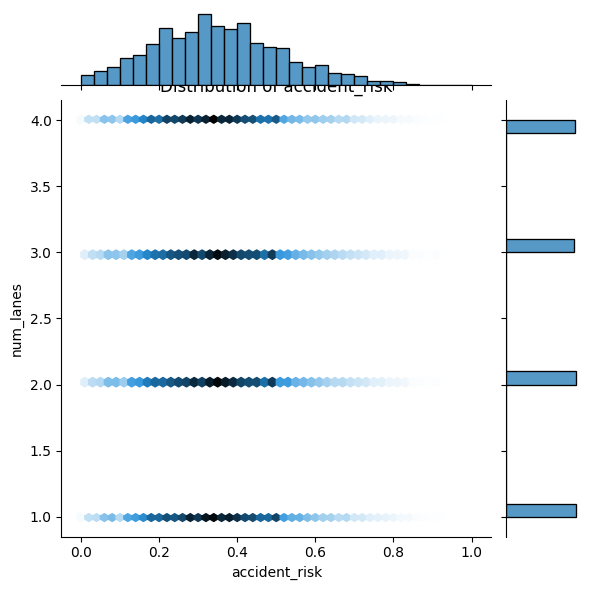

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 200x200 with 0 Axes>

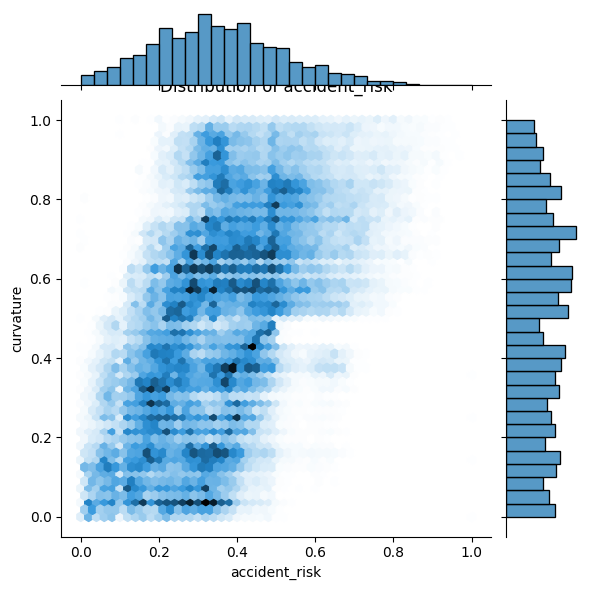

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 200x200 with 0 Axes>

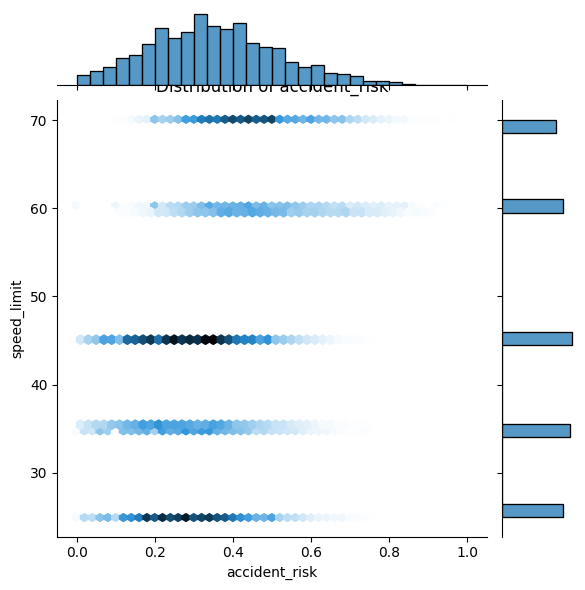

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 200x200 with 0 Axes>

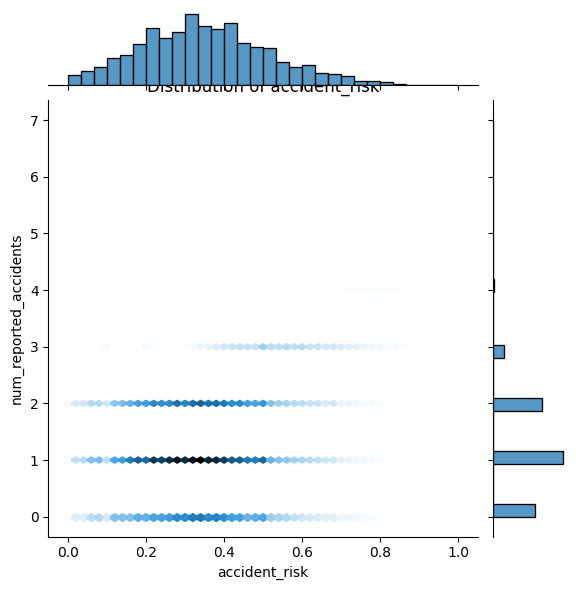

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Figure size 200x200 with 0 Axes>

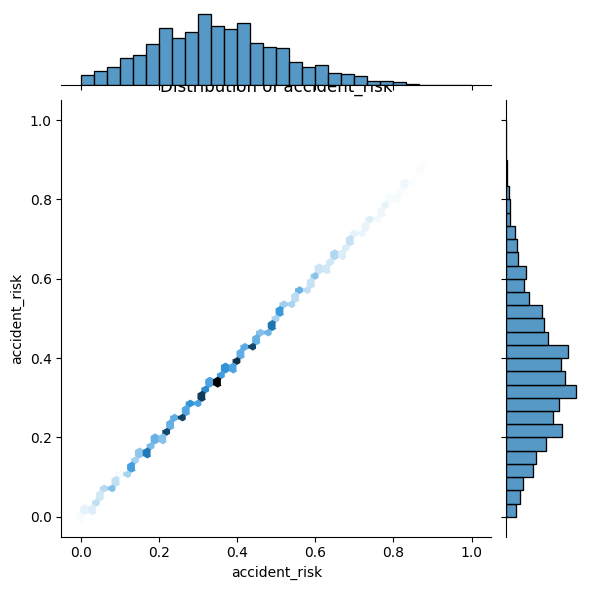

In [5]:
for num_feature in numerical_features:
    plt.figure(figsize=(2, 2))
    sns.jointplot(data=train_pd, x='accident_risk', kind='hex',marginal_kws=dict(bins=30), y=num_feature)  # kde + bins for smoother look
    plt.xlabel(feature)
    plt.ylabel(num_feature)
    plt.title(f"Distribution of {feature}")
    plt.show()
    

In [6]:
feature_boxplot = categorical_features + ['num_reported_accidents', 'speed_limit', 'num_lanes']

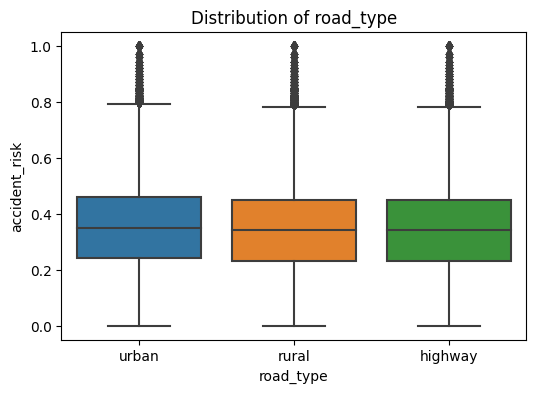

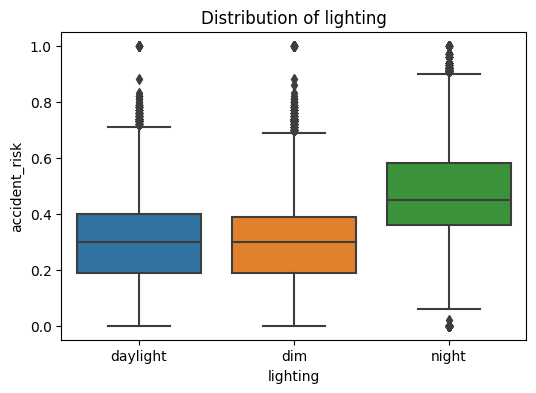

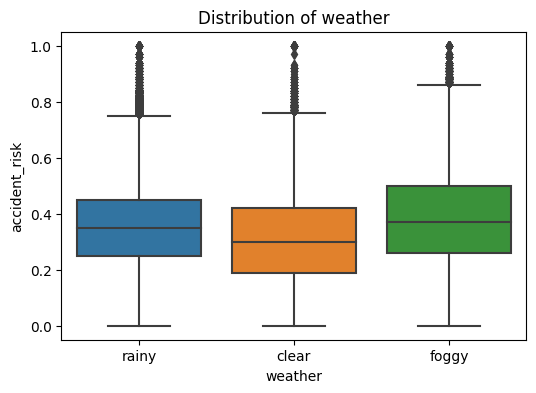

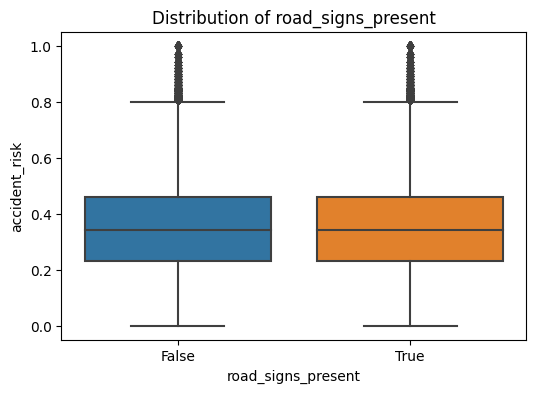

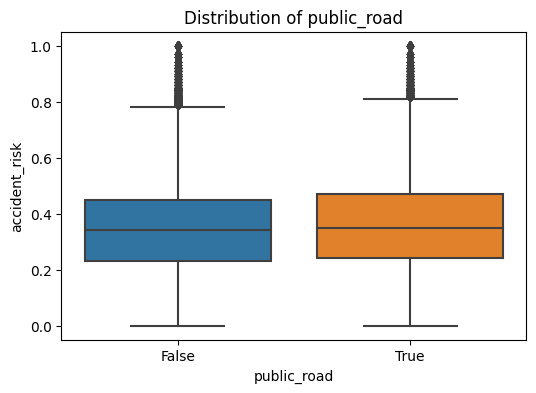

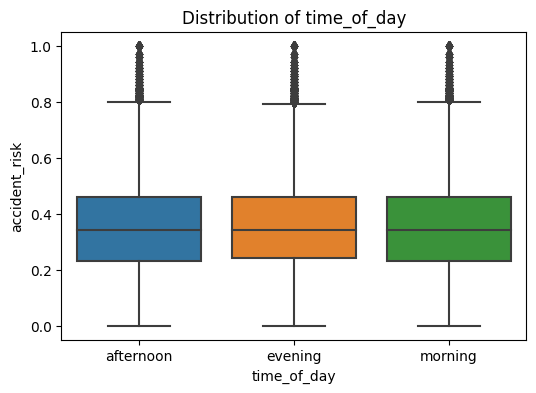

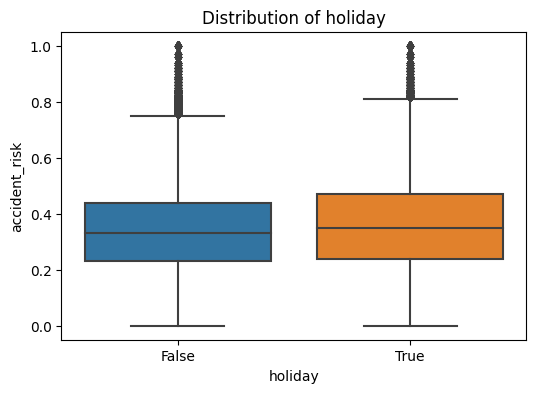

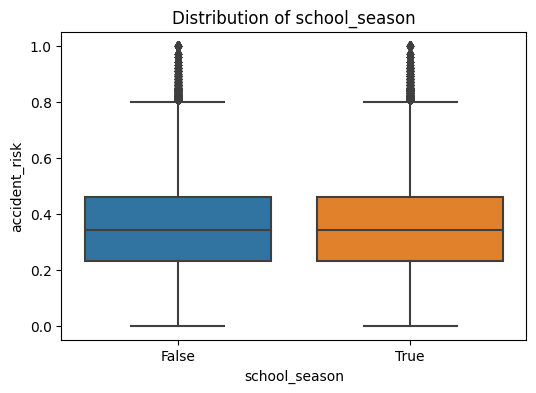

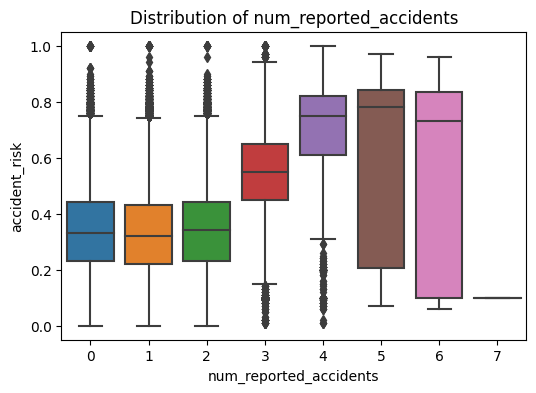

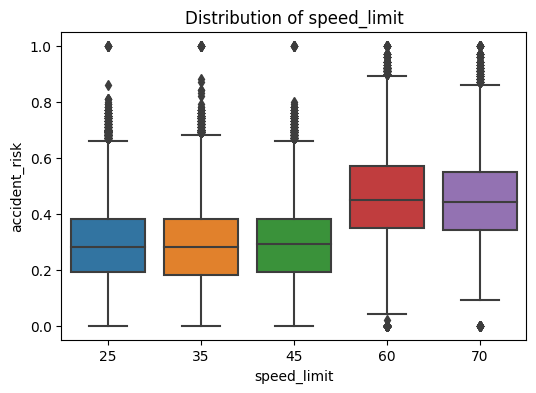

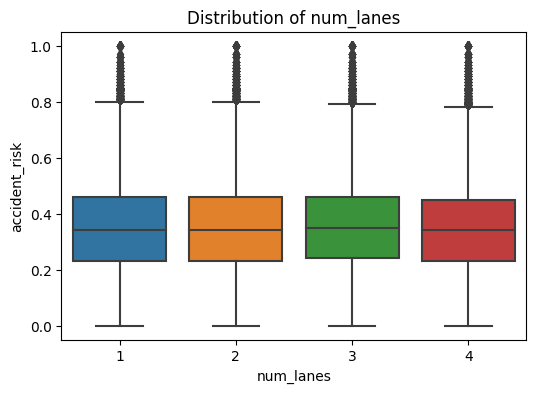

In [7]:
for feature in feature_boxplot:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=train_pd, x=feature, y='accident_risk') 
    plt.xlabel(feature)
    plt.ylabel('accident_risk')
    plt.title(f"Distribution of {feature}")
    plt.show()

In [8]:
train_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [9]:
from sklearn.model_selection import train_test_split

# Correct way: Separate features from target before splitting
X = train_pd.drop(columns=['accident_risk', 'id'], axis=1)  # Features only
y = train_pd['accident_risk']               # Target only

X_train, X_val, y_train, y_val = train_test_split(X, y, shuffle=True, test_size=0.2, random_state=42)

In [10]:
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((414203, 12), (103551, 12), (414203,), (103551,))

In [11]:
X_train = pd.get_dummies(X_train, columns=categorical_features, prefix_sep='_', drop_first=False)
X_train.head()

,num_lanes,curvature,speed_limit,num_reported_accidents,road_type_highway,road_type_rural,road_type_urban,lighting_daylight,lighting_dim,lighting_night,...,road_signs_present_True,public_road_False,public_road_True,time_of_day_afternoon,time_of_day_evening,time_of_day_morning,holiday_False,holiday_True,school_season_False,school_season_True
143159,2,0.43,60,2,False,True,False,False,True,False,...,False,True,False,True,False,False,False,True,False,True
20172,4,0.18,25,1,True,False,False,False,False,True,...,False,True,False,True,False,False,False,True,True,False
57926,1,0.20,70,1,False,False,True,False,False,True,...,False,False,True,False,False,True,False,True,False,True
193319,3,0.81,60,1,False,False,True,True,False,False,...,True,True,False,False,True,False,False,True,False,True
213938,3,0.43,35,2,False,True,False,False,False,True,...,False,False,True,False,False,True,False,True,False,True


In [12]:
X_val = pd.get_dummies(X_val, columns=categorical_features, prefix_sep='_', drop_first=False)
X_val.head()

,num_lanes,curvature,speed_limit,num_reported_accidents,road_type_highway,road_type_rural,road_type_urban,lighting_daylight,lighting_dim,lighting_night,...,road_signs_present_True,public_road_False,public_road_True,time_of_day_afternoon,time_of_day_evening,time_of_day_morning,holiday_False,holiday_True,school_season_False,school_season_True
50309,1,0.09,45,2,True,False,False,False,True,False,...,False,True,False,True,False,False,False,True,True,False
95219,4,0.14,60,0,False,False,True,True,False,False,...,False,False,True,False,False,True,False,True,True,False
197653,2,0.51,25,0,True,False,False,False,True,False,...,True,False,True,False,True,False,True,False,True,False
111236,1,0.33,60,1,False,True,False,True,False,False,...,False,False,True,False,False,True,True,False,False,True
147247,4,0.12,60,1,False,False,True,True,False,False,...,False,False,True,True,False,False,True,False,True,False


In [13]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
import optuna
import warnings


# Let's use copy of training dataset
X_copy = X.copy()
X_copy = pd.get_dummies(X_copy, columns=categorical_features, prefix_sep='_', drop_first=False)
y_copy = y.copy()

# Suppress all warnings
warnings.filterwarnings('ignore')
'''
def objective_with_validation_split(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'num_leaves': trial.suggest_int('num_leaves', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 50, 200),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
        'objective': 'regression',
        'metric': 'rmse',
        'subsample_freq': 1,
        'verbosity' : -1,
        'random_state': 42,
        'n_jobs': -1,  # Use all CPU cores instead of GPU
        # REMOVE these GPU parameters:
        # 'device': 'cuda',
        # 'gpu_platform_id': 0,
        # 'gpu_device_id': 0,
    }

    model = lgb.LGBMRegressor(**params)

    # Split data into train and validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_copy, y_copy, test_size=0.2, random_state=42, shuffle=True
    )

    # Fit the model
    model.fit(X_train, y_train)
    
    # Predict on validation set
    y_pred = model.predict(X_val)
    
    # Calculate RMSE
    rmse = mean_squared_error(y_val, y_pred, squared=False)
    
    # Return negative RMSE (since Optuna maximizes, and we want to minimize RMSE)
    return -rmse

study_lgb = optuna.create_study(study_name='LGBMRegbase fine tuning', direction='maximize')
study_lgb.optimize(objective_with_validation_split, n_trials=1000)

# Get best parameters:
best_params_lgb = study_lgb.best_params
print(f"Best RMSE: {study_lgb.best_value:.4f}")
print("Best parameters:", best_params_lgb)
'''
'''
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store RMSE for each fold
fold_rmse = []

X = train_pd.drop(columns=["id", "accident_risk"])
y = train_pd["accident_risk"]

# 5-Fold CV
for train_idx, val_idx in kf.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    
    X_train = pd.get_dummies(X_train, columns=categorical_features, prefix_sep='_', drop_first=False)
    
    X_val = pd.get_dummies(X_val, columns=categorical_features, prefix_sep='_', drop_first=False)
    
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
    XGBRegbase.fit(X_train, y_train)
    preds = XGBRegbase.predict(X_val)
        
    rmse = mean_squared_error(y_val, preds, squared=False)
    fold_rmse.append(rmse)
    
print(f"XGBRegbase mean RMSE: {np.mean(fold_rmse):.4f}")
'''

'\nkf = KFold(n_splits=5, shuffle=True, random_state=42)\n\n# Store RMSE for each fold\nfold_rmse = []\n\nX = train_pd.drop(columns=["id", "accident_risk"])\ny = train_pd["accident_risk"]\n\n# 5-Fold CV\nfor train_idx, val_idx in kf.split(X):\n    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]\n    \n    X_train = pd.get_dummies(X_train, columns=categorical_features, prefix_sep=\'_\', drop_first=False)\n    \n    X_val = pd.get_dummies(X_val, columns=categorical_features, prefix_sep=\'_\', drop_first=False)\n    \n    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]\n        \n    XGBRegbase.fit(X_train, y_train)\n    preds = XGBRegbase.predict(X_val)\n        \n    rmse = mean_squared_error(y_val, preds, squared=False)\n    fold_rmse.append(rmse)\n    \nprint(f"XGBRegbase mean RMSE: {np.mean(fold_rmse):.4f}")\n'

XGBRegbase = XGBRegressor(n_estimators = 500,
                         max_depth = 3,
                         learning_rate = 0.1,
                         subsample = 0.8,
                         colsample_bytree = 0.8,
                         reg_lambda = 1,
                         reg_alpha = 0,
                         objective='reg:squarederror',
                         eval_metric='rmse',
                         verbose=1,
                         random_state=42)

* XGBRegbase mean RMSE: 0.0565
* LGBRegbase mean RMSE: 0.0600

In [14]:
#import optuna.visualization as vis

#display(vis.plot_param_importances(study_lgb))
#display(vis.plot_optimization_history(study_lgb))

In [15]:
# XGB

'''XGBRegbase = xgb.XGBRegressor(n_estimators = 500,
                         max_depth = 3,
                         learning_rate = 0.1,
                         subsample = 0.8,
                         colsample_bytree = 0.8,
                         reg_lambda = 1,
                         reg_alpha = 0,
                         objective='reg:squarederror',
                         eval_metric='rmse',
                         random_state=42)

# Parameters used for v10
XGBRegoptuna1 = xgb.XGBRegressor(**{'n_estimators': 699, 
                                  'max_depth': 8, 
                                  'learning_rate': 0.010108705451891645, 
                                  'subsample': 0.6402784898024437, 
                                  'colsample_bytree': 0.9668274209321512, 
                                  'reg_lambda': 2.203450773706666,
                                  'reg_alpha': 0.002492531872446458}, 
                                   objective='reg:squarederror',
                                   eval_metric='rmse',
                                   random_state=42)
'''

# LGB
'''
LGBRegbase = lgb.LGBMRegressor(
    num_leaves=1000,
    max_depth=500,
    learning_rate=0.1,
    n_estimators=1000,
    min_data_in_leaf=100,
    colsample_bytree=0.8,  # Feature sampling
    subsample=0.8,         # Row sampling (bagging_fraction)
    subsample_freq=1,      # Enable bagging every iteration
    reg_lambda=1,
    reg_alpha=0,
    objective='regression',
    metric='rmse',         # Evaluation metric
    random_state=42        # Good practice for reproducibility
)
'''

"\nLGBRegbase = lgb.LGBMRegressor(\n    num_leaves=1000,\n    max_depth=500,\n    learning_rate=0.1,\n    n_estimators=1000,\n    min_data_in_leaf=100,\n    colsample_bytree=0.8,  # Feature sampling\n    subsample=0.8,         # Row sampling (bagging_fraction)\n    subsample_freq=1,      # Enable bagging every iteration\n    reg_lambda=1,\n    reg_alpha=0,\n    objective='regression',\n    metric='rmse',         # Evaluation metric\n    random_state=42        # Good practice for reproducibility\n)\n"

In [16]:
# XGB
#XGBRegoptuna1.fit(X_copy, y_copy)

# LGB
'''
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store RMSE for each fold
fold_rmse = []

X = train_pd.drop(columns=["id", "accident_risk"])
y = train_pd["accident_risk"]

# 5-Fold CV
for train_idx, val_idx in kf.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    
    X_train = pd.get_dummies(X_train, columns=categorical_features, prefix_sep='_', drop_first=False)
    
    X_val = pd.get_dummies(X_val, columns=categorical_features, prefix_sep='_', drop_first=False)
    
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
    LGBRegbase.fit(X_train, y_train)
    preds = LGBRegbase.predict(X_val)
        
    rmse = mean_squared_error(y_val, preds, squared=False)
    fold_rmse.append(rmse)
    
print(f"LGBRegbase mean RMSE: {np.mean(fold_rmse):.4f}")
'''


#X_val = pd.get_dummies(X_val, columns=categorical_features, prefix_sep='_', drop_first=False)
#y_pred_val = XGBRegbase.predict(X_val)

#print(f"XGBRegbase on test set mean RMSE: {mean_squared_error(y_val, y_pred_val, squared=False):.4f}")

'\nkf = KFold(n_splits=5, shuffle=True, random_state=42)\n\n# Store RMSE for each fold\nfold_rmse = []\n\nX = train_pd.drop(columns=["id", "accident_risk"])\ny = train_pd["accident_risk"]\n\n# 5-Fold CV\nfor train_idx, val_idx in kf.split(X):\n    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]\n    \n    X_train = pd.get_dummies(X_train, columns=categorical_features, prefix_sep=\'_\', drop_first=False)\n    \n    X_val = pd.get_dummies(X_val, columns=categorical_features, prefix_sep=\'_\', drop_first=False)\n    \n    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]\n        \n    LGBRegbase.fit(X_train, y_train)\n    preds = LGBRegbase.predict(X_val)\n        \n    rmse = mean_squared_error(y_val, preds, squared=False)\n    fold_rmse.append(rmse)\n    \nprint(f"LGBRegbase mean RMSE: {np.mean(fold_rmse):.4f}")\n'

In [17]:
best_params_lgb_v2 = {'n_estimators' : 5000 ,'num_leaves': 2320, 'max_depth': 7, 'learning_rate': 0.010261194451028046, 'subsample': 0.8334444883201919, 'min_data_in_leaf': 104, 'colsample_bytree': 0.9668215878324868, 'reg_lambda': 0.4362985902558426, 'reg_alpha': 1.4281065639641164}

In [18]:
#LGBRegbase.fit(X_copy, y_copy)
LGBReg_fine_tuned_v2 = lgb.LGBMRegressor(
    **best_params_lgb_v2,     
    objective='regression',
    metric='rmse',         # Evaluation metric      # Good practice for reproducibility
    n_jobs=-1,
    random_state = 42
)

LGBReg_fine_tuned_v2.fit(X_copy, y_copy)

[LightGBM] [Warning] min_data_in_leaf is set=104, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=104
[LightGBM] [Warning] min_data_in_leaf is set=104, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=104
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014658 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 187
[LightGBM] [Info] Number of data points in the train set: 517754, number of used features: 24
[LightGBM] [Info] Start training from score 0.352377
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

LGBMRegressor(colsample_bytree=0.9668215878324868,
              learning_rate=0.010261194451028046, max_depth=7, metric='rmse',
              min_data_in_leaf=104, n_estimators=5000, n_jobs=-1,
              num_leaves=2320, objective='regression', random_state=42,
              reg_alpha=1.4281065639641164, reg_lambda=0.4362985902558426,
              subsample=0.8334444883201919)

In [19]:
test_pd = pd.read_csv('/kaggle/input/playground-series-s5e10/test.csv')
X_test = pd.get_dummies(test_pd, columns=categorical_features, prefix_sep='_', drop_first=False)
X_test = X_test.drop(columns=['id'])

In [20]:
X_test.head()

,num_lanes,curvature,speed_limit,num_reported_accidents,road_type_highway,road_type_rural,road_type_urban,lighting_daylight,lighting_dim,lighting_night,...,road_signs_present_True,public_road_False,public_road_True,time_of_day_afternoon,time_of_day_evening,time_of_day_morning,holiday_False,holiday_True,school_season_False,school_season_True
0,2,0.34,45,1,True,False,False,False,False,True,...,True,False,True,True,False,False,False,True,False,True
1,3,0.04,45,0,False,False,True,False,True,False,...,True,True,False,True,False,False,False,True,True,False
2,2,0.59,35,1,False,False,True,False,True,False,...,True,True,False,True,False,False,False,True,False,True
3,4,0.95,35,2,False,True,False,True,False,False,...,False,True,False,True,False,False,True,False,True,False
4,2,0.86,35,3,True,False,False,True,False,False,...,True,True,False,False,True,False,True,False,False,True


In [21]:
# Now predict
submission_lgb_v2 = LGBReg_fine_tuned_v2.predict(X_test)
# submission = XGBRegbase.predict(X_test)
submission = pd.DataFrame({'id': test_pd.id, 'accident_risk': submission_lgb_v2})
submission.to_csv('/kaggle/working/submission.csv', index=False)
submission.head()

[LightGBM] [Warning] min_data_in_leaf is set=104, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=104


,id,accident_risk
0,517754,0.292863
1,517755,0.121943
2,517756,0.182647
3,517757,0.315561
4,517758,0.399505
